# Import der genutzten Bibliotheken

Installiere die notwendigen Bibliotheken, falls notwendig

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
# import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.seasonal import STL
import ipywidgets as widgets
from IPython.display import display, clear_output
import yfinance as yf

#register_matplotlib_converters()
#sns.set_style("darkgrid")

In [ ]:
#plt.rc("figure", figsize=(16, 12))
#plt.rc("font", size=13)

# Datensatz einlesen: "Monthly car sales"

Ein Automobilhersteller möchte seine monatlichen Verkaufszahlen analysieren, um langfristige Entwicklungen und saisonale Effekte besser zu verstehen.

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"

df_carSales = pd.read_csv(url)
df_carSales["Month"] = pd.to_datetime(df_carSales["Month"])
df_carSales.set_index("Month", inplace=True)

df_carSales.head()

,Sales
Month,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


# Aufgabe 1:

1. Visualisiere die Zeitreihe.
2. Führe eine STL-Zerlegung mit period=12 durch.
3. Überführe die zerlegten Zeitreihen in ein lesbares Data-Frame zur Weiterverarbeitung.
4. Warum ist eine Trennung von Trend und Saison für spätere Prognosemodelle hilfreich?

In [ ]:
# Füge hier deinen Code ein.

In [ ]:
# In DataFrame umwandeln
df_carSale_stl = pd.DataFrame({
    "observed": res_robust.observed,
    "trend": res_robust.trend,
    "seasonal": res_robust.seasonal,
    "resid": res_robust.resid
})

print(df_carSale_stl.head())

# Aufgabe 2: 

1. Führe die nachfolgende Zelle aus.
2. Nutze die Schieberegler, um die optimalen Parameter für die STL-Zerlegung zu finden.
3. Beschreibe, wie die Parameter period, seasonal, trend und robust jeweils das Ergebnis beeinflussen
4. Welcher Parameter hat den größten Einfluss? Wie wird er bestimmt?

In [ ]:
def plot_stl(period=12, seasonal=13, trend=21, robust=True):
    clear_output(wait=True)

    # STL benötigt ungerade Werte für seasonal und trend
    if seasonal % 2 == 0:
        seasonal += 1
    if trend % 2 == 0:
        trend += 1

    result = STL(
        df_carSales,
        period=period,
        seasonal=seasonal,
        trend=trend,
        robust=robust
    ).fit()

    fig = result.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle(
        f"STL-Zerlegung: period={period}, seasonal={seasonal}, trend={trend}, robust={robust}",
        y=1.02
    )
    plt.show()


period_slider = widgets.IntSlider(
    value=12,
    min=2,
    max=52,
    step=1,
    description="period"
)

seasonal_slider = widgets.IntSlider(
    value=13,
    min=7,
    max=51,
    step=2,
    description="seasonal"
)

trend_slider = widgets.IntSlider(
    value=21,
    min=7,
    max=101,
    step=2,
    description="trend"
)

robust_checkbox = widgets.Checkbox(
    value=True,
    description="robust"
)

ui = widgets.VBox([
    period_slider,
    seasonal_slider,
    trend_slider,
    robust_checkbox,
])

out = widgets.interactive_output(
    plot_stl,
    {
        "period": period_slider,
        "seasonal": seasonal_slider,
        "trend": trend_slider,
        "robust": robust_checkbox
    }
)

display(ui, out)

Output()

# Aufgabe 3: 

1. Bestimme den Parameter "seasonal" grafisch

# Datensatz einlesen: "Apple Aktienkurs"

In [4]:
# Apple-Aktie laden
df = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Schlusskurse auswählen
ts = df["Close"]

print(ts.head())

[*********************100%***********************]  1 of 1 completed

Ticker           AAPL
Date                 
2015-01-02  24.192604
2015-01-05  23.511057
2015-01-06  23.513271
2015-01-07  23.842979
2015-01-08  24.759075


# Aufgabe 4

1. Visualisiere die Daten 
2. Führe eine STL-Zerlegung durch
3. Wie hast du den "period" Parameter festgelegt?
4. Welche Aussagekraft hat die Saisonkomponente? Keine
5. Was sollte vor der Verwendung von STL immer überprüft werden? Wann ist eine STL-Zerlegung sinnvoll? Periodizität in den Daten

In [ ]:
# Füge hier deinen Code ein.

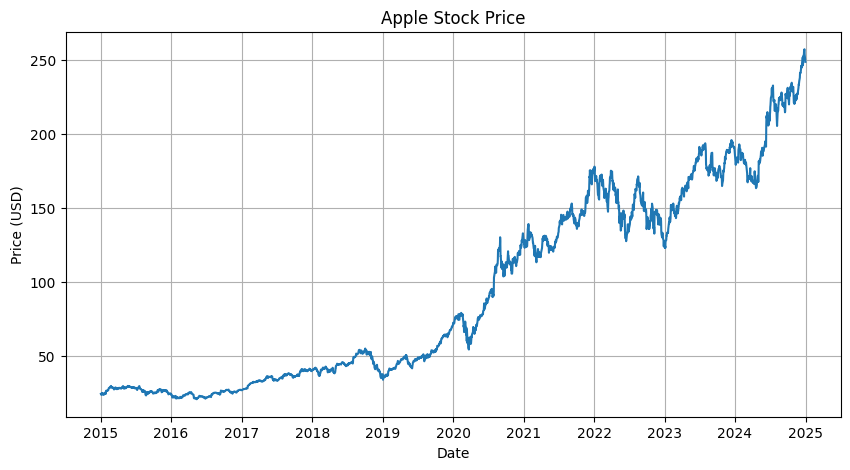

In [5]:
plt.figure(figsize=(10,5))
plt.plot(ts)
plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

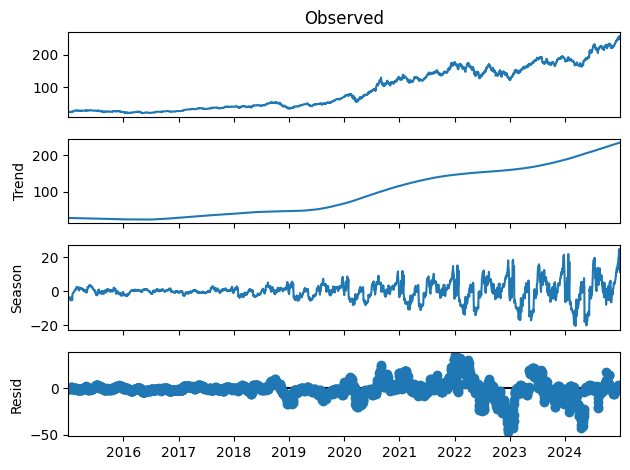

In [6]:
from statsmodels.tsa.seasonal import STL

stl = STL(
    ts,
    period=252,      # ca. 252 Handelstage pro Jahr
    seasonal=13,
    robust=True
)

result = stl.fit()

result.plot()
plt.show()